# AEMO Multi-Market Battery Trading — Simulation & Evaluation

This notebook runs agents in the **AEMOBatteryTradingEnv** with `multi_market` mode,
logs results (like `test_simrun.ipynb`), and evaluates performance (like `test_eval.ipynb`).

## Sections
1. **Setup** — imports, AEMO data fetch, environment creation
2. **Simulation** — run rule-based and RL agents, save logs to parquet
3. **Evaluation** — load logs, compute metrics, diagnostic plots, action comparison

---
## 1. Setup

In [1]:
import multiprocessing
multiprocessing.set_start_method("spawn", force=True)

import sys, os
sys.path.insert(0, 'src')

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path

In [2]:
from AEMOBatteryEnv import (
    AEMOBatteryTradingEnv,
    AEMODataPreprocessor,
    create_aemo_env_from_data,
)
from aemo_data import (
    fetch_aemo_data_bundle,
    fetch_aemo_unit_dispatch,
    get_available_battery_units,
    get_dispatch_active_battery_units,
    check_aemo_dispatch_availability,
    AEMO_REGIONS,
    FCAS_SERVICES,
)

# --- Configuration ---------------------------------------------------------
REGION = AEMO_REGIONS[1]  # e.g. "QLD1" (index 0=NSW1, 1=QLD1, 2=SA1, 3=TAS1, 4=VIC1)
START_DATE = datetime(2024, 1, 1)
END_DATE   = datetime(2024, 1, 7)      # one week of data
ROOT = Path.cwd().parent
CACHE_DIR  = "data/aemo"
OUTPUT_DIR = ROOT / "data/aemo_sim_output"
EVAL_DIR   = ROOT / "eval_output/aemo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

RUN_TAG = "aemo_mm"  # prefix for saved log files

# Optional manual override for dispatch replay unit
DISPATCH_DUID_OVERRIDE = None  # e.g. "LBBG1"
DISPATCH_UNIT_INDEX = 0        # used when override is None (index in displayed battery list)
DISPATCH_APPLY_UNIT_SIZING = True  # if True, use selected DUID capacity/power for dispatch replay env
DISPATCH_FETCH_START_DATE = START_DATE
DISPATCH_FETCH_END_DATE = END_DATE  # reduce this window while debugging if the container is memory constrained

# Environment parameters (default/base)
BATTERY_CAPACITY = 10.0   # MWh
MAX_BATTERY_FLOW = 5.0    # MW
INIT_SOC         = 5.0    # MWh (50 %)
STEP_DURATION    = 0.5    # hours (30-min intervals)
BATTERY_LIFE_COST = 1_000_000.0  # USD

NUM_EPISODES = 3  # number of parallel episodes to collect

print(f"Region: {REGION}")
print(f"Date range: {START_DATE.date()} → {END_DATE.date()}")
print(f"output dir: {OUTPUT_DIR}")

Region: QLD1
Date range: 2024-01-01 → 2024-01-07
output dir: /code/data/aemo_sim_output


### 1.1 Fetch & preprocess AEMO data

In [3]:
# Fetch raw AEMO data (prices, FCAS, generation)
raw_data = fetch_aemo_data_bundle(
    start_date=START_DATE,
    end_date=END_DATE,
    region=REGION,
    fcas_services=["RAISEREG", "LOWERREG", "RAISE6SEC", "LOWER6SEC",
                   "RAISE60SEC", "LOWER60SEC", "RAISE5MIN", "LOWER5MIN"],
    fuel_types=["solar", "wind"],
    cache_dir=CACHE_DIR,
)

preprocessor = AEMODataPreprocessor(step_duration_hours=STEP_DURATION)
processed_data = preprocessor.preprocess_aemo_data(
    prices=raw_data["prices"],
    fcas=raw_data["fcas"],
    generation=raw_data["generation"],
)
print(f"Processed data: {processed_data.height} rows, {processed_data.width} cols")
print(f"Columns: {processed_data.columns}")

Fetching AEMO data bundle for QLD1 from 2024-01-01 to 2024-01-07...
Fetching dispatch price data for QLD1 from 2024-01-01 to 2024-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Downloading data for table DISPATCHPRICE, year 2023, month 12
INFO: Creating feather file for DISPATCHPRICE, 2023, 12
INFO: Downloading data for table DISPATCHPRICE, year 2024, month 01
INFO: Creating feather file for DISPATCHPRICE, 2024, 01
INFO: Returning DISPATCHPRICE.
INFO: Compiling data for table DISPATCHREGIONSUM
INFO: Downloading data for table DISPATCHREGIONSUM, year 2023, month 12
INFO: Creating feather file for DISPATCHREGIONSUM, 2023, 12
INFO: Downloading data for table DISPATCHREGIONSUM, year 2024, month 01
INFO: Creating feather file for DISPATCHREGIONSUM, 2024, 01
INFO: Returning DISPATCHREGIONSUM.
Fetched 1728 price records
Fetching FCAS RAISEREG price data for QLD1 from 2024-01-01 to 2024-01-07...
INFO: Compiling data for table DISPATCHPRICE
INFO: Returning DISPATCHPRICE.
Fetched 17

### 1.2 Create multi-market environments

We create several independent environments (different random episode start indices on reset)
so we can collect multiple episodes in parallel — just like `test_simrun.ipynb` does
with household data.

In [ ]:

# Each env is an independent instance sharing the same preprocessed data
envs = [
    AEMOBatteryTradingEnv(
        aemo_data=processed_data,
        battery_capacity=BATTERY_CAPACITY,
        max_battery_flow=MAX_BATTERY_FLOW,
        init_battery_level=INIT_SOC,
        max_step=288,               # ~3 days at 30-min resolution
        step_duration=STEP_DURATION,
        battery_life_cost=BATTERY_LIFE_COST,
        action_mode="multi_market",
        degradation_mode="rainflow",
    )
    for _ in range(NUM_EPISODES)
]

print(f"Created {len(envs)} multi-market AEMO environments")
print(f"Obs space : {envs[0].observation_space}")
print(f"Act space : {envs[0].action_space}  (energy_dispatch, fcas_raise, fcas_lower)")

Created 3 multi-market AEMO environments
Obs space : Box([-1. -1. -1. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.], 1.0, (18,), float32)
Act space : Box([-1.  0.  0.], 1.0, (3,), float32)  (energy_dispatch, fcas_raise, fcas_lower)


/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


---
## 2. Simulation — run agents & save logs

We run the same agent algorithms used in `test_simrun.ipynb`, adapted for the AEMO env.

### 2.1 Rule-based agent

In [ ]:
from decision import AEMOAgent, run_episodes_parallel

agent_kwargs_list = [
    {
        "algorithm": "rule",
        "reset_options": {"random_episode_start": True},
        "reset_seed": 1000 + i,   # optional; remove for non-reproducible random starts
    }
    for i in range(NUM_EPISODES)
]

rule_episode_logs, rule_incident_logs = run_episodes_parallel(
    AEMOAgent,
    envs,
    agent_kwargs=agent_kwargs_list,
    render=False,
    max_workers=NUM_EPISODES,
    use_notebook_tqdm=True,
)

In [ ]:
# Save rule agent logs
dfs_with_id = [
    df.with_columns(pl.lit(i).alias("episode_id"))
    for i, df in enumerate(rule_episode_logs)
]
rule_all_logs = pl.concat(dfs_with_id)

file_name = OUTPUT_DIR / f"{RUN_TAG}_rule_logs.parquet"
rule_all_logs.write_parquet(str(file_name))
print(f"Saved rule logs → {file_name}  ({rule_all_logs.height} rows)")

# Incident logs
incident_dfs = [
    df.with_columns(pl.lit(i).alias("episode_id"))
    for i, df in enumerate(rule_incident_logs)
    if df.height > 0
]
if incident_dfs:
    rule_inc = pl.concat(incident_dfs)
    inc_file = OUTPUT_DIR / f"{RUN_TAG}_rule_incident_logs.parquet"
    rule_inc.write_parquet(str(inc_file))
    print(f"Saved incident logs → {inc_file}")
else:
    print("[INFO] No incident logs to save.")

### 2.2 Dispatch replay agent (unit DUID from static table)

This section lists available battery units from the AEMO static table and supports two selectors:
- `DISPATCH_DUID_OVERRIDE` for explicit DUID selection
- `DISPATCH_UNIT_INDEX` for index-based selection from the displayed list

If `DISPATCH_APPLY_UNIT_SIZING=True`, the dispatch replay environment adopts selected-unit sizing
(capacity and max MW where available), while rule/RL sections keep the base environment settings.

In [4]:
# --- Dispatch replay setup from static battery unit list ----------------------
from decision import AEMOAgent, run_single

dispatch_episode_logs = []
dispatch_incident_logs = []

try:
    battery_units = get_available_battery_units(
        cache_dir=CACHE_DIR,
        region=REGION,
        refresh=False,
    )

    if battery_units.height == 0:
        print(f"[SKIP] No battery units found in static table for region={REGION}")
        DISPATCH_DUID = None
    else:
        battery_units = battery_units.sort(["StorageCapacityMWh", "RegisteredCapacityMW"], descending=[True, True], nulls_last=True)
        print(f"Available battery DUIDs in {REGION}: {battery_units.height}")
        display_cols = [
            c for c in ["DUID", "Region", "TechnologyType", "FuelType", "StorageCapacityMWh", "RegisteredCapacityMW"]
            if c in battery_units.columns
        ]
        print(battery_units.select(display_cols).head(20))

        if DISPATCH_DUID_OVERRIDE:
            DISPATCH_DUID = DISPATCH_DUID_OVERRIDE
        else:
            print(
                f"Finding dispatch-active battery DUIDs in {REGION} for "
                f"{DISPATCH_FETCH_START_DATE.date()} to {DISPATCH_FETCH_END_DATE.date()}..."
            )
            active_battery_units = get_dispatch_active_battery_units(
                start_date=DISPATCH_FETCH_START_DATE,
                end_date=DISPATCH_FETCH_END_DATE,
                region=REGION,
                cache_dir=CACHE_DIR,
            )

            if active_battery_units.height == 0:
                print(
                    f"[SKIP] No battery DUIDs from the static table appear in DISPATCHLOAD for "
                    f"{REGION} during {DISPATCH_FETCH_START_DATE.date()} to {DISPATCH_FETCH_END_DATE.date()}."
                )
                DISPATCH_DUID = None
            else:
                print(f"Dispatch-active battery DUIDs in {REGION}: {active_battery_units.height}")
                active_display_cols = [
                    c for c in [
                        "DUID",
                        "Region",
                        "TechnologyType",
                        "FuelType",
                        "DispatchIntervalCount",
                        "FirstDispatchInterval",
                        "LastDispatchInterval",
                    ]
                    if c in active_battery_units.columns
                ]
                print(active_battery_units.select(active_display_cols).head(20))

                selected_idx = max(0, min(int(DISPATCH_UNIT_INDEX), active_battery_units.height - 1))
                DISPATCH_DUID = active_battery_units["DUID"][selected_idx]
                battery_units = active_battery_units

        if DISPATCH_DUID is None:
            pass
        else:
            availability = check_aemo_dispatch_availability(
                start_date=DISPATCH_FETCH_START_DATE,
                end_date=DISPATCH_FETCH_END_DATE,
                duid=DISPATCH_DUID,
                cache_dir=CACHE_DIR,
            )
            print(
                f"Dispatch availability for {DISPATCH_DUID}: has_data={availability['has_data']}, "
                f"rows={availability['row_count']}, intervals={availability['unique_intervals']}/"
                f"{availability['expected_intervals']}, coverage={availability['coverage_ratio']:.2%}"
            )
            print(
                f"First interval: {availability['first_settlement']}, "
                f"Last interval: {availability['last_settlement']}"
            )

            if not availability["has_data"]:
                print(
                    f"[SKIP] DUID {DISPATCH_DUID} has no DISPATCHLOAD rows in the chosen range "
                    f"{DISPATCH_FETCH_START_DATE.date()} to {DISPATCH_FETCH_END_DATE.date()}."
                )
                DISPATCH_DUID = None

        if DISPATCH_DUID is None:
            pass
        else:
            chosen = battery_units.filter(pl.col("DUID") == DISPATCH_DUID).head(1)
            print(f"Selected dispatch DUID: {DISPATCH_DUID}")
            print(
                f"Dispatch fetch request -> {DISPATCH_FETCH_START_DATE.date()} to "
                f"{DISPATCH_FETCH_END_DATE.date()}"
            )

            suggested_mwh = None
            suggested_mw = None
            if chosen.height > 0:
                suggested_mwh = chosen["StorageCapacityMWh"][0] if "StorageCapacityMWh" in chosen.columns else None
                suggested_mw = chosen["RegisteredCapacityMW"][0] if "RegisteredCapacityMW" in chosen.columns else None
                print(f"Suggested env sizing from static table -> capacity={suggested_mwh} MWh, max_flow={suggested_mw} MW")

            dispatch_battery_capacity = BATTERY_CAPACITY
            dispatch_max_flow = MAX_BATTERY_FLOW
            if DISPATCH_APPLY_UNIT_SIZING:
                if suggested_mwh is not None and np.isfinite(suggested_mwh) and suggested_mwh > 0:
                    dispatch_battery_capacity = float(suggested_mwh)
                if suggested_mw is not None and np.isfinite(suggested_mw) and suggested_mw > 0:
                    dispatch_max_flow = float(suggested_mw)

            init_soc_ratio = (INIT_SOC / BATTERY_CAPACITY) if BATTERY_CAPACITY > 0 else 0.5
            dispatch_init_soc = float(np.clip(dispatch_battery_capacity * init_soc_ratio, 0.0, dispatch_battery_capacity))

            print(
                f"Dispatch replay env params -> capacity={dispatch_battery_capacity:.3f} MWh, "
                f"max_flow={dispatch_max_flow:.3f} MW, init_soc={dispatch_init_soc:.3f} MWh"
            )

            dispatch_envs = [
                AEMOBatteryTradingEnv(
                    aemo_data=processed_data,
                    battery_capacity=dispatch_battery_capacity,
                    max_battery_flow=dispatch_max_flow,
                    init_battery_level=dispatch_init_soc,
                    max_step=288,
                    step_duration=STEP_DURATION,
                    battery_life_cost=BATTERY_LIFE_COST,
                    action_mode="multi_market",
                    degradation_mode="rainflow",
                )
                for _ in range(NUM_EPISODES)
            ]

            dispatch_df = fetch_aemo_unit_dispatch(
                start_date=DISPATCH_FETCH_START_DATE,
                end_date=DISPATCH_FETCH_END_DATE,
                duid=DISPATCH_DUID,
                cache_dir=CACHE_DIR,
            )
            print(f"Dispatch rows fetched for {DISPATCH_DUID}: {dispatch_df.height}")
            if dispatch_df.height > 0:
                print(dispatch_df.head(5))

            if dispatch_df.height == 0:
                print(f"[SKIP] No dispatch data returned for DUID={DISPATCH_DUID}")
            else:
                for idx, env in enumerate(dispatch_envs):
                    agent_kwargs = {
                        "algorithm": "dispatch",
                        "dispatch_data": dispatch_df,
                        "dispatch_duid": DISPATCH_DUID,
                    }
                    ep_df, inc_df = run_single(
                        AEMOAgent,
                        env,
                        agent_kwargs=agent_kwargs,
                        render=False,
                        display_progress=False,
                    )
                    dispatch_episode_logs.append(ep_df)
                    dispatch_incident_logs.append(inc_df)
                    print(f"  Dispatch episode {idx}: {ep_df.height} steps, reward={ep_df['reward'].sum():.2f}")

                dfs_with_id = [
                    df.with_columns(pl.lit(i).alias("episode_id"))
                    for i, df in enumerate(dispatch_episode_logs)
                ]
                dispatch_all_logs = pl.concat(dfs_with_id)
                out_file = OUTPUT_DIR / f"{RUN_TAG}_dispatch_logs.parquet"
                dispatch_all_logs.write_parquet(str(out_file))
                print(f"Saved dispatch logs → {out_file} ({dispatch_all_logs.height} rows)")

                incident_dfs = [
                    df.with_columns(pl.lit(i).alias("episode_id"))
                    for i, df in enumerate(dispatch_incident_logs)
                    if df.height > 0
                ]
                if incident_dfs:
                    dispatch_inc = pl.concat(incident_dfs)
                    inc_file = OUTPUT_DIR / f"{RUN_TAG}_dispatch_incident_logs.parquet"
                    dispatch_inc.write_parquet(str(inc_file))
                    print(f"Saved dispatch incident logs → {inc_file}")
                else:
                    print("[INFO] No dispatch incident logs to save.")
except Exception as e:
    print(f"[SKIP] Dispatch replay setup failed: {e}")
    DISPATCH_DUID = None

INFO: Retrieving static table Generators and Scheduled Loads
Available battery DUIDs in QLD1: 13
shape: (13, 6)
┌───────────┬────────┬──────────────────────┬──────────┬────────────────────┬──────────────────────┐
│ DUID      ┆ Region ┆ TechnologyType       ┆ FuelType ┆ StorageCapacityMWh ┆ RegisteredCapacityMW │
│ ---       ┆ ---    ┆ ---                  ┆ ---      ┆ ---                ┆ ---                  │
│ str       ┆ str    ┆ str                  ┆ str      ┆ f64                ┆ f64                  │
╞═══════════╪════════╪══════════════════════╪══════════╪════════════════════╪══════════════════════╡
│ TARBESS1  ┆ QLD1   ┆ Battery and Inverter ┆ Grid     ┆ 600.0              ┆ 393.0                │
│ SNB01     ┆ QLD1   ┆ Battery and Inverter ┆ Grid     ┆ 545.0              ┆ 337.4                │
│ WDBESS2   ┆ QLD1   ┆ Battery and Inverter ┆ Grid     ┆ 510.0              ┆ 269.8                │
│ SWANBBF1  ┆ QLD1   ┆ Battery and Inverter ┆ Grid     ┆ 500.0              ┆ 33

/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.10/dist-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


INFO: Returning DISPATCHLOAD.
    DUID filter: 829440 records before filter, 1728 after filtering for 'KEPBL1'
Fetched 1728 dispatch records for 1 unique units
Dispatch rows fetched for KEPBL1: 1728
shape: (5, 11)
┌────────────┬────────┬────────────┬───────────┬───┬───────────┬────────────┬───────────┬──────────┐
│ SETTLEMENT ┆ DUID   ┆ TOTALCLEAR ┆ RAISE6SEC ┆ … ┆ LOWER6SEC ┆ LOWER60SEC ┆ LOWER5MIN ┆ LOWERREG │
│ DATE       ┆ ---    ┆ ED         ┆ ---       ┆   ┆ ---       ┆ ---        ┆ ---       ┆ ---      │
│ ---        ┆ str    ┆ ---        ┆ f64       ┆   ┆ f64       ┆ f64        ┆ f64       ┆ f64      │
│ datetime[n ┆        ┆ f64        ┆           ┆   ┆           ┆            ┆           ┆          │
│ s]         ┆        ┆            ┆           ┆   ┆           ┆            ┆           ┆          │
╞════════════╪════════╪════════════╪═══════════╪═══╪═══════════╪════════════╪═══════════╪══════════╡
│ 2024-01-01 ┆ KEPBL1 ┆ 0.0        ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0        ┆ 0

/code/src/decision.py:621: UserWarning: Dispatch actions are all zero after aligning with the environment grid. Possible causes:
  1. TOTALCLEARED is zero for all intervals (battery was not dispatched for energy).
  2. RAISEREG/LOWERREG are zero (battery did not provide regulation FCAS).
  3. Timestamp mismatch between dispatch data and environment data.
Check that the selected DUID was actively dispatched during the date range. For batteries that only provide contingency FCAS (RAISE6SEC, LOWER6SEC, etc.), consider using the paired gen/load DUID approach via dispatch_duid_gen and dispatch_duid_load arguments.
  self.set_dispatch_data(


### 2.2.1 Visualise dispatch replay episode

Use `EpisodeVisualizer()` to inspect the first dispatch replay episode, either from the in-memory `dispatch_episode_logs` list or from a saved parquet log if you rerun the notebook later.

Using in-memory dispatch episode logs.
shape: (5, 3)
┌──────┬──────────────────┬────────┐
│ step ┆ action           ┆ reward │
│ ---  ┆ ---              ┆ ---    │
│ i64  ┆ list[f32]        ┆ f64    │
╞══════╪══════════════════╪════════╡
│ 0    ┆ [-0.0, 0.0, 0.0] ┆ 0.0    │
│ 1    ┆ [-0.0, 0.0, 0.0] ┆ 0.0    │
│ 2    ┆ [-0.0, 0.0, 0.0] ┆ 0.0    │
│ 3    ┆ [-0.0, 0.0, 0.0] ┆ 0.0    │
│ 4    ┆ [-0.0, 0.0, 0.0] ┆ 0.0    │
└──────┴──────────────────┴────────┘


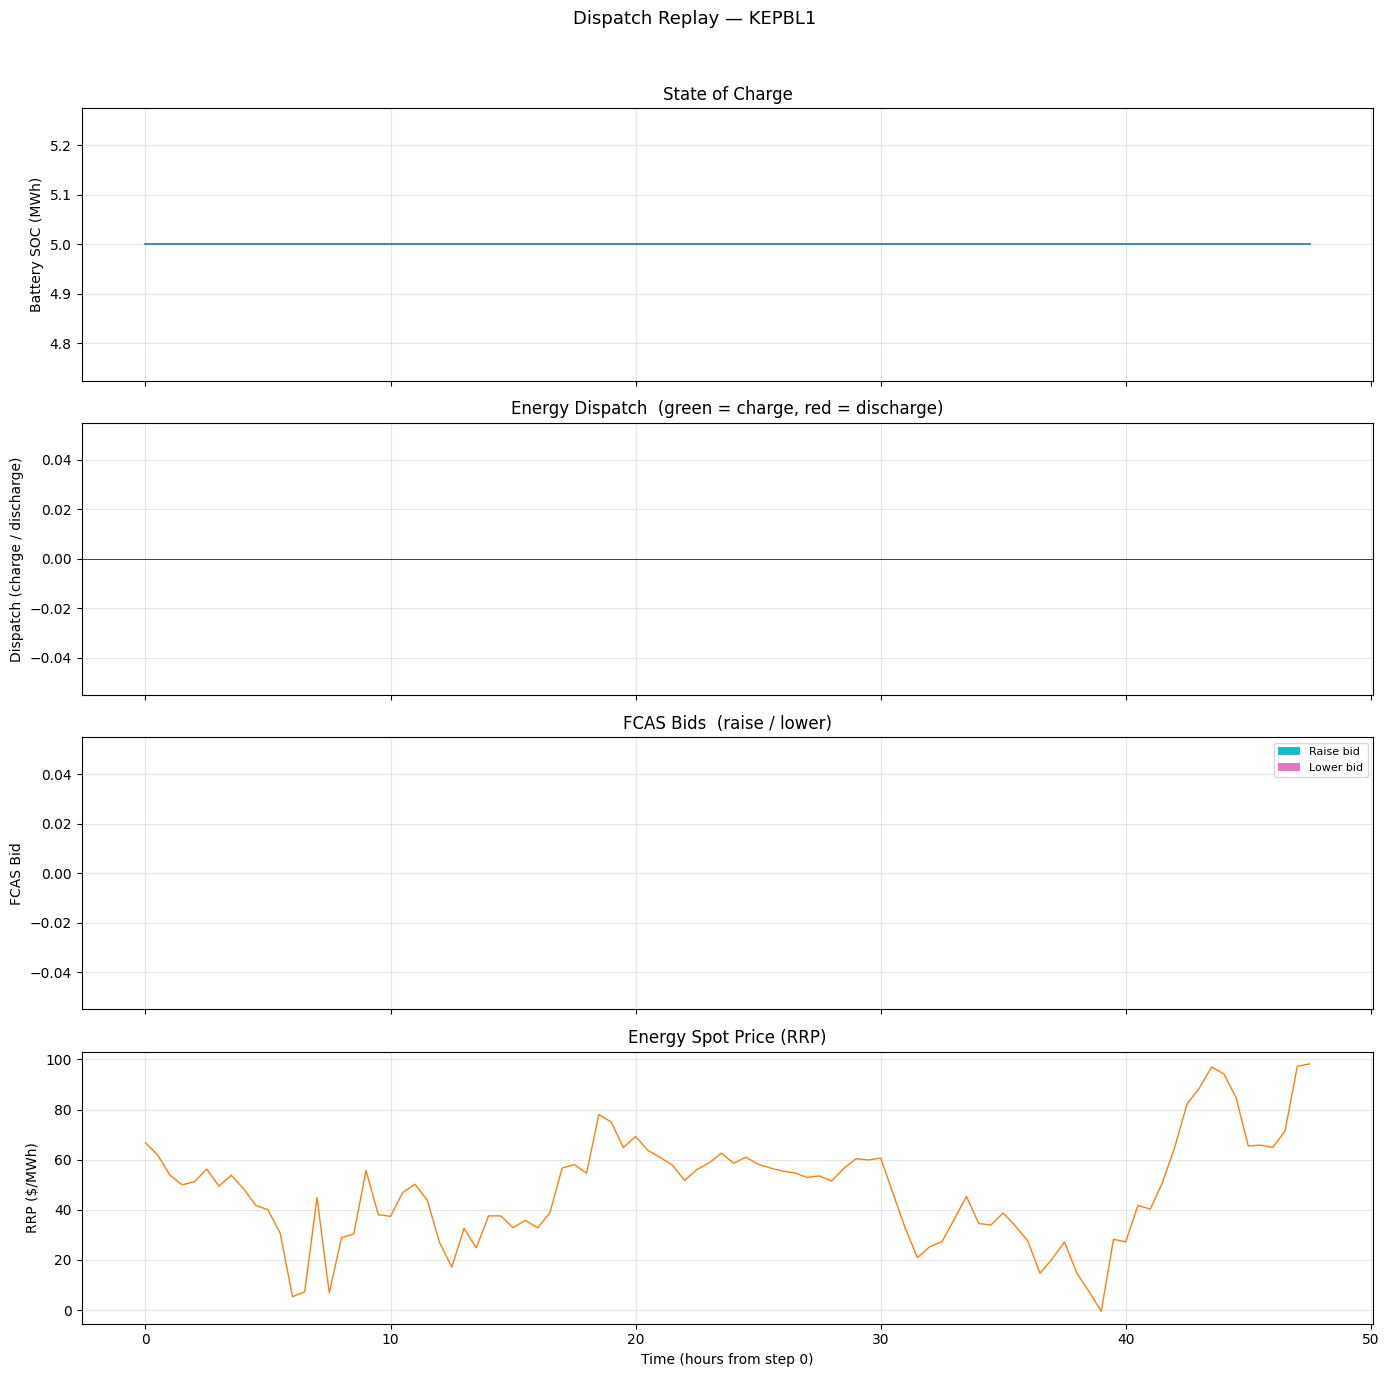

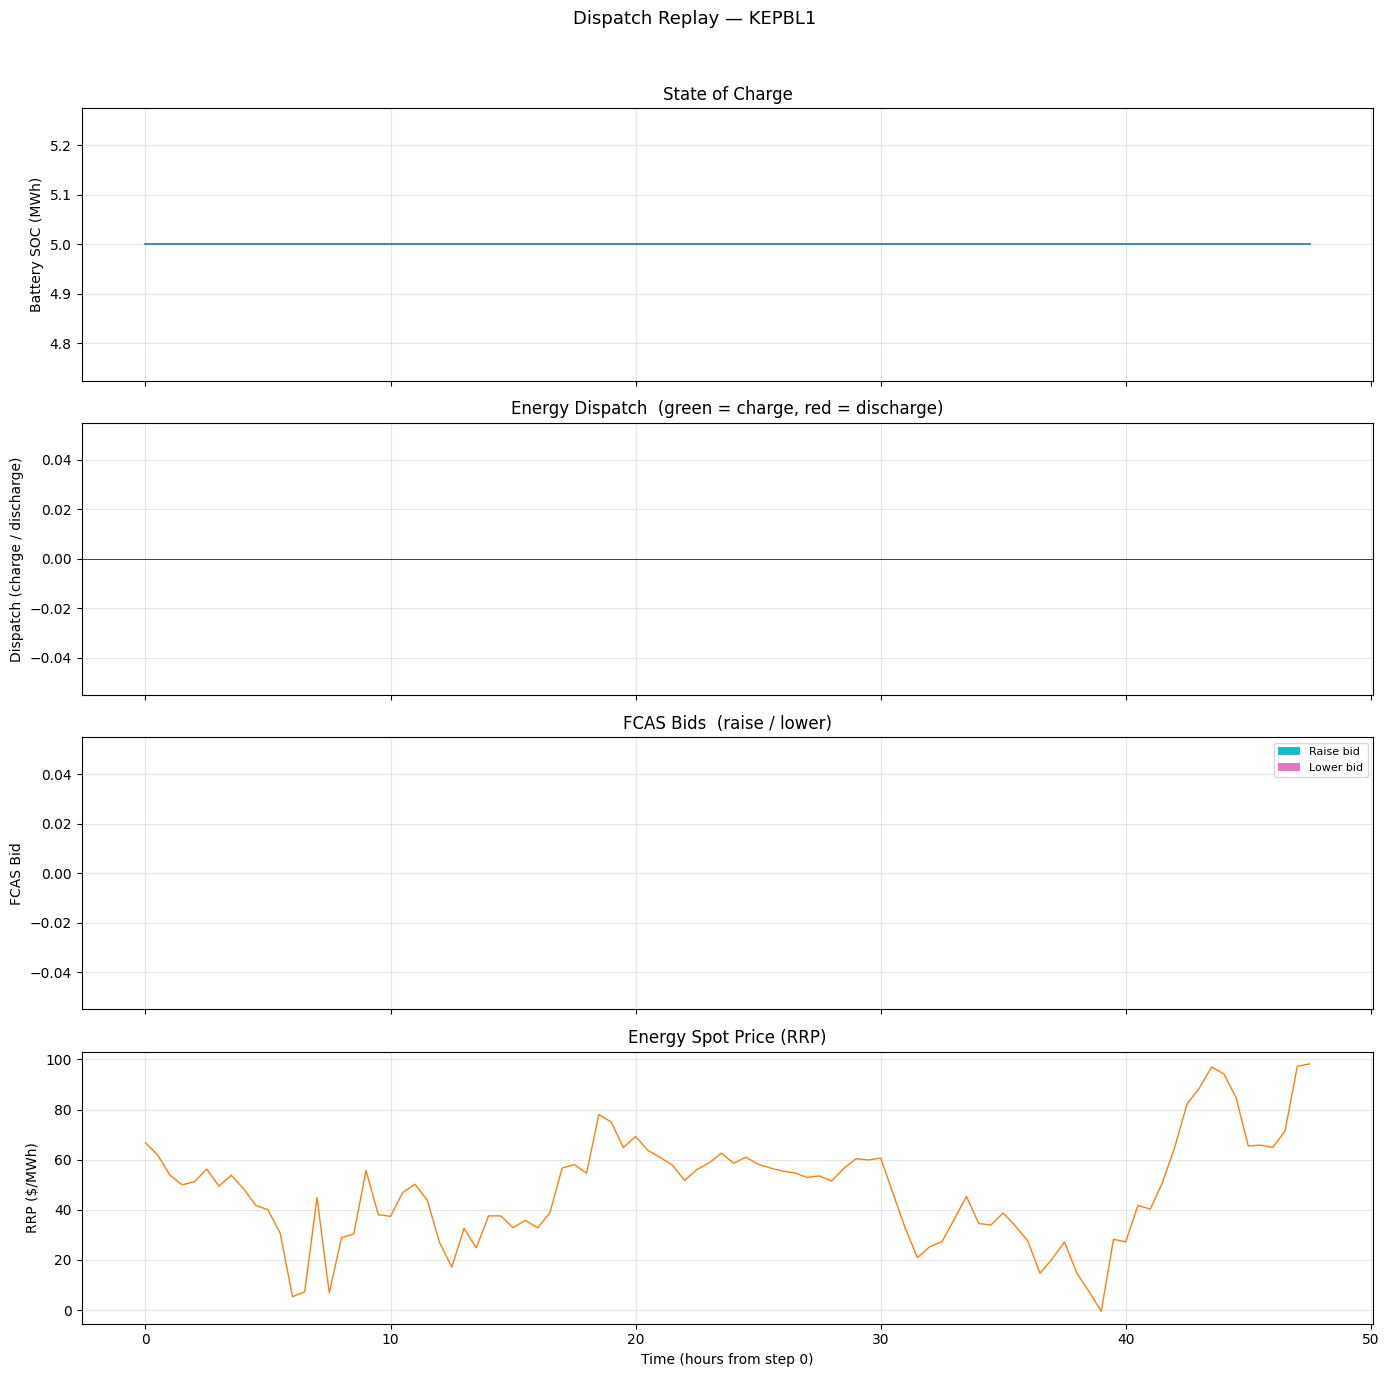

In [5]:
from helper import EpisodeVisualizer

def load_dispatch_episode_for_visualization():
    if "dispatch_episode_logs" in globals() and len(dispatch_episode_logs) > 0:
        print("Using in-memory dispatch episode logs.")
        return dispatch_episode_logs[0]

    candidate_paths = [
        OUTPUT_DIR / f"{RUN_TAG}_dispatch_logs.parquet",
        ROOT / "data/aemo_sim_output" / f"{RUN_TAG}_dispatch_logs.parquet",
        ROOT / "src/data/aemo_sim_output" / f"{RUN_TAG}_dispatch_logs.parquet",
    ]

    for path in candidate_paths:
        if path.exists():
            print(f"Loading saved dispatch logs from {path}")
            df = pl.read_parquet(str(path))
            if "episode_id" in df.columns:
                episode_ids = sorted(df["episode_id"].unique().to_list())
                if not episode_ids:
                    raise ValueError(f"No episode_id values found in {path}")
                return df.filter(pl.col("episode_id") == episode_ids[0]).drop("episode_id")
            return df

    raise FileNotFoundError(
        "No dispatch episode logs found in memory or on disk. "
        "Run the dispatch replay cell first."
    )

dispatch_vis_df = load_dispatch_episode_for_visualization()
print(dispatch_vis_df.select([c for c in ["step", "action", "reward"] if c in dispatch_vis_df.columns]).head(5))

dispatch_vis = EpisodeVisualizer(
    dispatch_vis_df,
    step_duration=STEP_DURATION,
    env_type="aemo",
)
dispatch_fig = dispatch_vis.plot(
    start_step=0,
    num_hours=min(48.0, max(STEP_DURATION, dispatch_vis_df.height * STEP_DURATION)),
    title=f"Dispatch Replay — {DISPATCH_DUID or 'saved dispatch episode'}",
    x_axis_mode="elapsed",
    show=True,
 )
dispatch_fig

### 2.3 SB3 RL agents (optional — requires trained models)

If you have SB3 models trained on the AEMO env, load and evaluate them here.
Otherwise this section is skipped gracefully.

In [ ]:
from decision import AEMOAgent, run_single

# --- Attempt to load SB3 models trained on AEMO multi-market env -----------
rl_models = {}  # label -> (model, algorithm_name)

try:
    from stable_baselines3 import PPO, SAC, A2C, DDPG, TD3

    model_candidates = {
        "sac":  (SAC,  "models/aemo_sac_model.zip"),
        "ppo":  (PPO,  "models/aemo_ppo_model.zip"),
        "a2c":  (A2C,  "models/aemo_a2c_model.zip"),
        "ddpg": (DDPG, "models/aemo_ddpg_model.zip"),
        "td3":  (TD3,  "models/aemo_td3_model.zip"),
    }

    for label, (cls, path) in model_candidates.items():
        if os.path.exists(path):
            model = cls.load(path)
            rl_models[label] = model
            print(f"Loaded {label.upper()} from {path}")
        else:
            print(f"[SKIP] {path} not found")
except ImportError:
    print("[SKIP] stable-baselines3 not installed")

print(f"\nRL models available: {list(rl_models.keys()) or 'none'}")

In [ ]:
# Run each RL model as an AEMOAgent with algorithm='rl'
rl_all_episode_logs = {}  # label -> list[pl.DataFrame]

for label, model in rl_models.items():
    print(f"\n--- Running {label.upper()} agent ---")
    ep_logs = []
    for idx, env in enumerate(envs):
        agent_kwargs = {"algorithm": "rl", "model": model}
        ep_df, inc_df = run_single(AEMOAgent, env, agent_kwargs=agent_kwargs, render=False)
        ep_logs.append(ep_df)
        print(f"  Episode {idx}: {ep_df.height} steps, reward={ep_df['reward'].sum():.2f}")

    rl_all_episode_logs[label] = ep_logs

    # Save logs
    dfs_with_id = [df.with_columns(pl.lit(i).alias("episode_id")) for i, df in enumerate(ep_logs)]
    combined = pl.concat(dfs_with_id)
    out_file = OUTPUT_DIR / f"{RUN_TAG}_{label}_logs.parquet"
    combined.write_parquet(str(out_file))
    print(f"  Saved → {out_file}  ({combined.height} rows)")

if not rl_models:
    print("No RL models to run. Continuing with rule-based logs only.")

---
## 3. Evaluation

This section mirrors `test_eval.ipynb` — load all collected logs, compute metrics,
run diagnostics, and produce comparison plots.

### 3.1 Load logs into the evaluation dict

In [ ]:
import re

# Build the all_logs dict: label -> list[pl.DataFrame]  (one DF per episode)
# Start with already-in-memory logs from this session
all_logs: dict[str, list[pl.DataFrame]] = {}

# Rule logs (always present)
all_logs["rule"] = rule_episode_logs

# Dispatch logs (if collected)
if "dispatch_episode_logs" in globals() and len(dispatch_episode_logs) > 0:
    all_logs["dispatch"] = dispatch_episode_logs

# RL logs (if any were run)
all_logs.update(rl_all_episode_logs)

# Optionally, scan the output directory for previously saved parquet logs
for f in sorted(OUTPUT_DIR.glob(f"{RUN_TAG}_*_logs.parquet")):
    fname = f.stem  # e.g. aemo_mm_rule_logs
    # extract the algorithm label between the tag prefix and _logs suffix
    m = re.match(rf"^{re.escape(RUN_TAG)}_(.+?)_logs$", fname)
    if not m:
        continue
    label = m.group(1)
    if label in all_logs:
        continue  # already loaded from memory
    try:
        df = pl.read_parquet(str(f))
        if df.height == 0:
            continue
        if "episode_id" not in df.columns:
            df = df.with_columns(pl.lit(0).alias("episode_id"))
        eps = [df.filter(pl.col("episode_id") == eid) for eid in df["episode_id"].unique()]
        all_logs[label] = eps
        print(f"Loaded {label} from {f.name}: {len(eps)} episodes, {df.height} rows")
    except Exception as e:
        print(f"[WARN] Failed to load {f.name}: {e}")

print(f"\nAll labels: {list(all_logs.keys())}")
for lbl, eps in all_logs.items():
    print(f"  {lbl}: {len(eps)} episodes")

### 3.2 Problematic-episode diagnostics

In [ ]:
from helper import find_problematic_episodes

problems, suggested_return_scale = find_problematic_episodes(all_logs)
print(f"Suggested return scale: {suggested_return_scale}")
print(f"Problematic episodes found: {len(problems)}")

for p in problems[:10]:  # show first 10
    print(p)

### 3.3 Evaluate experiments — metrics & plots

In [ ]:
from helper import evaluate_experiments

metrics = evaluate_experiments(
    all_logs,
    target_return=0.0,
    save_dir=str(EVAL_DIR),
)

# Save metrics CSV
metrics_csv = EVAL_DIR / "evaluation_metrics.csv"
metrics.write_csv(str(metrics_csv))
print(f"Saved evaluation metrics → {metrics_csv}")
metrics

In [ ]:
# Print rankings
import pandas as pd

mdf = metrics.to_pandas().set_index("experiment")

print("Mean reward ranking (higher is better):")
print(mdf["mean_reward"].sort_values(ascending=False))

if "sharpe_ratio" in mdf.columns:
    print("\nSharpe ratio ranking (higher is better):")
    print(mdf["sharpe_ratio"].sort_values(ascending=False))

### 3.4 Per-episode inspection

In [ ]:
# Pick the first algorithm & first episode for a quick visual inspection
inspect_algo = list(all_logs.keys())[0]
inspect_ep   = 0

df = all_logs[inspect_algo][inspect_ep]
print(f"Inspecting: {inspect_algo}, episode {inspect_ep}  ({df.height} steps)")

# Extract info-dict fields if present
def extract_info_field(df, field):
    """Safely extract a field from the info column (dict or JSON string)."""
    import json, ast
    vals = []
    for info in df["info"]:
        if info is None:
            vals.append(None)
        elif isinstance(info, dict):
            vals.append(info.get(field))
        else:
            try:
                j = json.loads(info) if isinstance(info, str) else info
                vals.append(j.get(field) if isinstance(j, dict) else None)
            except Exception:
                try:
                    j = ast.literal_eval(info)
                    vals.append(j.get(field) if isinstance(j, dict) else None)
                except Exception:
                    vals.append(None)
    return vals

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Rewards
axes[0].plot(df["reward"].to_list(), linewidth=0.8)
axes[0].set_ylabel("Reward")
axes[0].set_title(f"{inspect_algo} — Episode {inspect_ep}")
axes[0].grid(alpha=0.3)

# SOC
soc_vals = extract_info_field(df, "battery_soc")
axes[1].plot(soc_vals, linewidth=0.8, color="tab:green")
axes[1].set_ylabel("Battery SOC (MWh)")
axes[1].grid(alpha=0.3)

# Energy price
price_vals = extract_info_field(df, "energy_price")
axes[2].plot(price_vals, linewidth=0.8, color="tab:orange")
axes[2].set_ylabel("Energy Price ($/MWh)")
axes[2].grid(alpha=0.3)

# Actions
actions = df["action"].to_list()
if actions and isinstance(actions[0], list):
    energy_actions = [a[0] for a in actions]
    axes[3].plot(energy_actions, linewidth=0.8, label="energy dispatch")
    if len(actions[0]) >= 3:
        axes[3].plot([a[1] for a in actions], linewidth=0.8, alpha=0.6, label="FCAS raise bid")
        axes[3].plot([a[2] for a in actions], linewidth=0.8, alpha=0.6, label="FCAS lower bid")
    axes[3].legend(fontsize=8)
else:
    axes[3].plot(actions, linewidth=0.8)
axes[3].set_ylabel("Action")
axes[3].set_xlabel("Step")
axes[3].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(EVAL_DIR / "episode_inspection.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved episode inspection plot → {EVAL_DIR / 'episode_inspection.png'}")

### 3.5 Degradation analysis

In [ ]:
# Plot degradation metrics from the info dict
deg_vals = extract_info_field(df, "step_degradation")
total_deg = extract_info_field(df, "total_degradation")
cap_vals  = extract_info_field(df, "capacity_mwh")

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(deg_vals, linewidth=0.8, color="tab:red")
axes[0].set_ylabel("Step Degradation")
axes[0].set_title(f"Degradation — {inspect_algo} ep {inspect_ep}")
axes[0].grid(alpha=0.3)

axes[1].plot(total_deg, linewidth=0.8, color="tab:purple")
axes[1].set_ylabel("Cumulative Degradation")
axes[1].grid(alpha=0.3)

axes[2].plot(cap_vals, linewidth=0.8, color="tab:blue")
axes[2].set_ylabel("Capacity (MWh)")
axes[2].set_xlabel("Step")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6 Action comparison (pairwise vs reference)

In [ ]:
# Only run action comparison if we have more than one algorithm
if len(all_logs) > 1:
    from helper import AlgorithmActionComparator, ActionComparisonConfig

    def compare_action_pairwise_to_reference(
        logs_dict, reference, base_save_dir=None, **kwargs
    ):
        comparator = AlgorithmActionComparator(action_logs=logs_dict)
        results = {}
        for algo in logs_dict:
            if algo == reference:
                continue
            sub_logs = {reference: logs_dict[reference], algo: logs_dict[algo]}
            kw = dict(kwargs)
            if base_save_dir:
                out = Path(base_save_dir) / f"{reference}_vs_{algo}"
                out.mkdir(parents=True, exist_ok=True)
                kw["save_dir"] = str(out)
            cfg = ActionComparisonConfig(reference=reference, **kw)
            results[algo] = comparator.compare(logs_dict=sub_logs, config=cfg)
        return results

    pairwise_results = compare_action_pairwise_to_reference(
        all_logs,
        reference="rule",
        base_save_dir=str(EVAL_DIR),
        bins="auto",
        max_episodes=20,
    )
    print("Pairwise comparison complete for:", list(pairwise_results.keys()))
else:
    print("Only one algorithm available — skipping pairwise action comparison.")

### 3.7 Temporal analysis (optional)

In [ ]:
# Temporal analysis on a single episode across algorithms
if len(all_logs) > 1:
    from helper import AlgorithmActionComparator, TemporalAnalysisConfig

    # Pick episode 0 from each algorithm for temporal overlay
    episode_single = {}
    for algo, logs in all_logs.items():
        if len(logs) > 0:
            episode_single[algo] = logs[0]

    if len(episode_single) > 1:
        steps_per_hour = int(1 / STEP_DURATION)
        two_day_steps = 2 * 24 * steps_per_hour

        time_periods = [
            (0, min(two_day_steps, min(df.height for df in episode_single.values()))),
        ]

        comparator = AlgorithmActionComparator()
        cfg = TemporalAnalysisConfig(
            time_periods=time_periods,
            annotate_states=True,
            step_duration=STEP_DURATION,
            reference="rule",
            action_tolerance=0.01,
            save_path=str(EVAL_DIR / "temporal"),
        )
        result = comparator.analyze_temporal(logs_dict=episode_single, config=cfg)
        print(result.stats)
        plt.show(result.figure)
    else:
        print("Need at least 2 algorithms for temporal comparison.")
else:
    print("Only one algorithm — skipping temporal analysis.")

---
## Summary

This notebook demonstrated the complete AEMO multi-market simulation and evaluation pipeline:

1. **Data** — Fetched and preprocessed AEMO NEM data (prices, FCAS, generation)
2. **Simulation** — Ran rule-based (and optionally RL) agents on `AEMOBatteryTradingEnv` in `multi_market` mode, logged to parquet
3. **Evaluation** — Computed performance metrics, diagnostic plots, action comparisons, and degradation analysis

### Next steps
- Train SB3 agents (PPO, SAC) on the multi-market AEMO environment
- Fine-tune a Decision Transformer on AEMO episode data
- Compare dispatch-replay agents against RL and rule-based baselines
- Analyse FCAS revenue contribution vs energy arbitrage